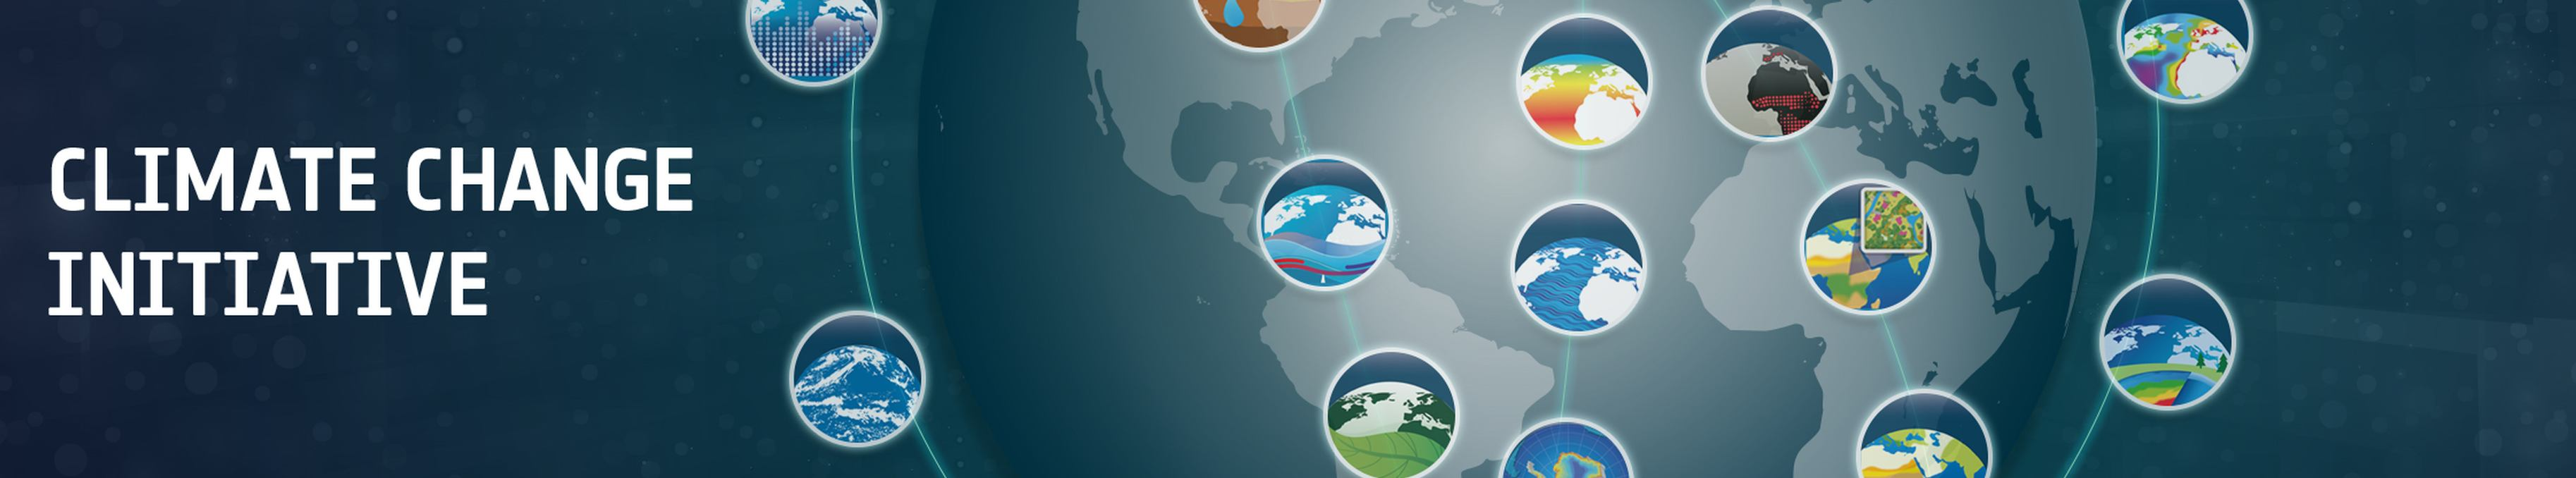

# Introduction

In October 2017, a series of devastating wildfires swept across Northern Portugal and Northwestern Spain, burning over 500,000 hectares in Portugal alone. What made these fires so extreme? In this notebook, we'll investigate that question using real satellite climate data from ESA's Climate Change Initiative (CCI).
By working through this notebook, you will:

- Learn to access and visualise ESA-CCI's ECVs
- Explore ESA-CCI's Fire data to analyse patterns across the Iberian Peninsula in 2017
- Analyse ESA-CCI's Soil Moisture anomalies to assess pre-fire drought conditions
- Examine ESA-CCI's Land Surface Temperature anomalies during the fire period
- Quantify ESA-CCI's Biomass loss caused by the fires using before/after comparisons


Prerequisites: Basic Python familiarity and some experience with NumPy or pandas. No prior experience with satellite data is required.
Estimated time: ~2 hours

🛠️ Tools We'll Use

We'll rely on the [**ESA Climate Toolbox**](https://esa-climate-toolbox.readthedocs.io/en/latest/) which simplifies access, manipulation, and visualisation of CCI datasets in Python.

New to the toolbox? For a broader introduction to the toolbox and how to install it, visit:  

🔗 [**ESA CCI Climate Toolbox Quick Start**](https://esa-climate-toolbox.readthedocs.io/en/latest/quick_start.html#jupyter-notebooks)  
🔗 [**ESA Climate Data Toolbox Website**](https://climate.esa.int/en/data/toolbox/)


The Toolbox package allows us to:

- access satellite-based climate data records from ESA's Climate Change Initiative (CCI)
- handle geospatial and temporal dimensions efficiently
- aggregate and visualise climate data with intuitive plotting tools spatially and temporally


Learning objectives:

By the end of this notebook, you will be able to:
- load and subset ESA CCI satellite datasets
- calculate climatological anomalies
- do a temporal aggregation a dataset

In [1]:
# ESA Climate Toolbox imports for accessing and plotting ESA CCI data
from esa_climate_toolbox.core import get_op              # Get predefined operations (e.g., time series, averages)
from esa_climate_toolbox.core import list_ecv_datasets   # List available datasets per ECV (Essential Climate Variable)
from esa_climate_toolbox.core import get_store           # Connect to an ESA data store
from esa_climate_toolbox.core import list_datasets       # List all datasets in a store
from esa_climate_toolbox.core import open_data           # Open datasets with the toolbox
from esa_climate_toolbox.ops import plot                 # High-level plotting functions for CCI data
from esa_climate_toolbox.ops import temporal_aggregation # Converting data into coarser time resolution based

# Used for connecting to remote data sources (e.g., ESA CCI ODP)
from xcube.core.store import new_data_store

# For displaying geographic regions interactively (if desired)
from IPython.display import GeoJSON
import shapely.geometry   # Handling geometric objects like bounding boxes
import folium

# Core data science libraries
import pandas as pd       # For tabular data handling and time manipulation
import numpy as np        # For numerical operations
import xarray as xr       # For multi-dimensional climate data structures

# Mapping and plotting
import matplotlib.pyplot as plt       # Plotting library
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs            # Cartographic projections for spatial data
import cartopy.feature as cfeature
import rasterio                       # Used to read GeoTIFF files

# Individual colormap creation
from matplotlib.colors import ListedColormap, BoundaryNorm

# Notebook settings
import warnings
warnings.filterwarnings("ignore") # Suppressing warnings to keep notebook output clean
%matplotlib inline

## Motivation 

This notebook will give some examples on how to use the ESA CCI climate toolbox, load and visualise datasets from the ESA CCI projects. 
As satellite data is rather large, the best practice is to minimise the data load by reducing it to an area of interest. 

### Real-World Application: Analysing the 2017 Iberian Wildfires with CCI Data

💡 In October 2017 Northern Portugal and Northwestern Spain experienced a series of forest fires. The fires had been fueled by strong winds from a previous Hurricane Ophelia. 
A study published in Nature Scientific Reports by [Turco et al. (2019)](https://www.nature.com/articles/s41598-019-50281-2) analysed the climatic factors which led to the extent of the fires. Alone in Portugal about 500 000 hectars were burned down by fires in 2017, where two fire events were happening, one from 17-20 June, the other from 15-17 October 2017. 

Several factors played a role in causing the extent of the fires. The year has been extremely dry and hot, both factors which have been shown to promote strong wild fires ([Turco et al., 2017](https://www.nature.com/articles/s41598-017-00116-9)).


Now, let's have a look at the satellite data ourselves and determine the conditions which favoured the wildfires in 2017.


👉 Let's start by looking at the monthly burned area on the Iberian Peninsula to narrow down to an area which has been majorly impacted. 

### 🛰️ CCI FIRE
We will use the data products from the [**CCI Fire**](https://climate.esa.int/en/projects/fire/) project and look at the burned area. Details about the dataset can be found on the project website and the provided [Product User Guide](https://climate.esa.int/media/documents/Fire_cci_D4.2.1_PUG-MODIS_v1.1.pdf).  

With the command `list_ecv_datasets('Fire')`, we can call a list of all available CCI Fire datasets which can be loaded via the esa-climate-toolbox.

Before loading the data, we can inspect its structure and look at the attributes, data variables, dimensions, etc. by using the toolbox command `describe_data`.

In [2]:
list_ecv_datasets('Fire')

[('esacci.FIRE.mon.L4.BA.MODIS.Terra.MODIS_TERRA.v5-1.grid', 'esa-cci'),
 ('esacci.FIRE.mon.L4.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.2-0.grid',
  'esa-cci'),
 ('esacci.FIRE.mon.L4.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.v1-1.grid',
  'esa-cci'),
 ('esacci.FIRE.mon.L4.BA.multi-sensor.multi-platform.SYN.v1-1.grid',
  'esa-cci'),
 ('esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v5-1.pixel', 'esa-cci'),
 ('esacci.FIRE.mon.L3S.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.2-0.pixel',
  'esa-cci'),
 ('esacci.FIRE.mon.L3S.BA.MSI-(Sentinel-2).Sentinel-2A.MSI.v1-1.pixel',
  'esa-cci'),
 ('esacci.FIRE.mon.L3S.BA.multi-sensor.multi-platform.SYN.v1-1.pixel',
  'esa-cci'),
 ('ESACCI-L4_FIRE-BA-MODIS-2001-2022-fv5.1.zarr', 'esa-cci-zarr')]

We will start with looking at the burned area to get an overview of the extent of the fires on the Iberian Peninsula. For this, we load the `'ESACCI-L4_FIRE-BA-MODIS-2001-2022-fv5.1.zarr'` file. 

Note: At the end of this notebook, we will link to another example, showing you how to explore the pixel dataset from the CCI Fire project which is provided as a datatree format.   

First, we will define the `data_id` and look at the opening parameters to get a better idea of the dataset and what it contains. 

In [3]:
fire_dataset = 'ESACCI-L4_FIRE-BA-MODIS-2001-2022-fv5.1.zarr'
cci_zarr_store = new_data_store("esa-cci-zarr")
cci_zarr_store.describe_data(fire_dataset)

##### What do we learn from the details?

The datatype of the datafile we chose is "dataset" and we can directly access the data after loading it without additional steps. 

The `data_vars` show us which data variables are included. We are interested in the `burned_area` and will therefore load this variable only, by defining the `var_names` in the `open_data` command (see next cell). The unit of the burned area is m<sup>2</sup> which can be found when clicking on the `data_vars` → `burned_area` → `attrs`.

From the `time_range` we learn that dataset is available from 2001 - 2022 in monthly resolution. The monthly resolution is not shown here in the meta data but we get this information from opening the dataset in the next cell and looking at the time data. The spatial resolution is 0.25° which corresponds to a pixel size of approximately 25 km x 25 km on the Iberian Peninsula. 


In [4]:
# open the dataset with the toolbox command open_data from the esa-climate-toolbox
fire_ds, fire_ds_name = open_data(fire_dataset, var_names="burned_area")
fire_ds

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 261, lat: 720, lon: 1440, vegetation_class: 18)
Coordinates:
  * lat               (lat) float32 3kB 89.88 89.62 89.38 ... -89.62 -89.88
  * lon               (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * time              (time) datetime64[ns] 2kB 2001-01-01 ... 2022-12-01
  * vegetation_class  (vegetation_class) int32 72B 10 20 30 40 ... 160 170 180
Data variables:
    burned_area       (time, lat, lon) float32 1GB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/37)
    Conventions:                CF-1.6
    cdm_data_type:              Grid
    comment:                    These data were produced as part of the ESA F...
    creator_email:              emilio.chuvieco@uah.es
    creator_name:               University of Alcala
    creator_url:                www.esa-fire-cci.org
    ...                         ...
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    summary:                    The grid product is the result of summing up ...
    time_coverage_end:          20221231T000000Z
    time_coverage_start:        20010101T000000Z
    title:                      Fire_cci Gridded MODIS Burned Area product
    tracking_id:                1209b4b8-32a1-4957-a80f-5b36913cac5b

## Zooming In - Defining a Region of Interest
Let's reduce the data size by focussing on the North Western part of the Iberian Peninsula. For your convenience, we also provide the bounding box for the whole Iberian Peninsula in case you would like to investigate a larger area. 

To reduce the dataset spatially, we define a bounding box (bbox) for the desired area and apply the `subset_spatial`operation from the esa-climate-toolbox on our dataset. 

In [5]:
# Set bounding box by defining the longitude minimum, latitude minimum, longitude maximum and latitude maximum
bbox_iberianpeninsula = (-10, 35.0, 5, 44.0) # Iberian Peninsula
bbox_west = (-9.5, 39.0, -6.0, 44.0) # North Western part of the Iberian Peninsula 

bbox = bbox_west

# Display bounding box for reference 
geom = shapely.geometry.box(*bbox)
centroid = geom.centroid

m = folium.Map(location=[centroid.y, centroid.x], zoom_start=7)

folium.GeoJson(geom.__geo_interface__).add_to(m)

m

In [6]:
# Building the subset and saving it into a new dataset called fire_sub
subset_spatial_op = get_op('subset_spatial')
fire_sub = subset_spatial_op(ds=fire_ds, region=bbox_west)

Now let's plot the months June and October of 2017 to look at the burned area these months. 

We will use the `plot_map` function from the toolbox.

In [7]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150  # here we can increase the resolution of the figures to make them look clearer

# Get the operator plot_map from the toolbox:
plot_map = get_op('plot_map')

Now we will do the actual plot:

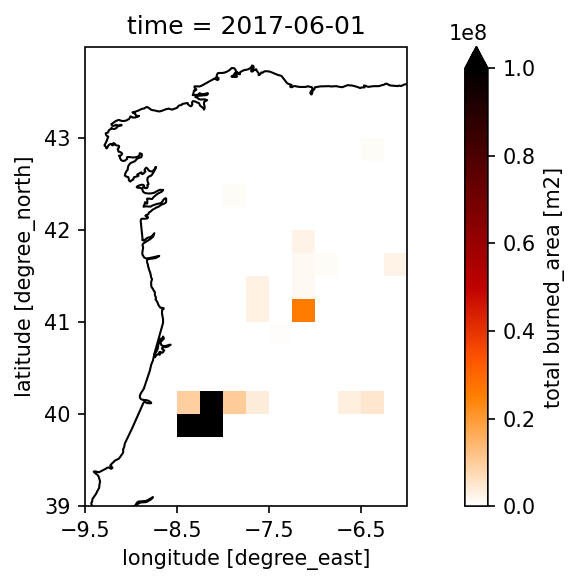

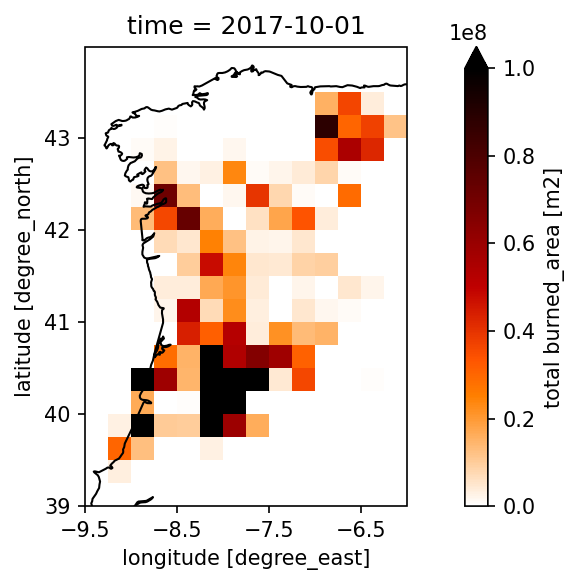

In [8]:
# Define the months to plot
dates = ['2017-06-01', '2017-10-01']

# Here is the actual plotting with the toolbox for June
plot_map(
    fire_sub.sel(time=dates[0], method='nearest'), # this is the dataset we want to plot, we chose the date from above via the for loop
    var="burned_area", # here we define the variable we would like to plot
    projection="PlateCarree", # here we define the projection for the plot
    region=bbox_west, # the bbox is used here to define the x and y limits which makes it easy as we already defined them above
    properties=dict(cmap="gist_heat_r", vmin=0, vmax=1e8, xticks=np.arange(bbox[0], bbox[2], 1), yticks=np.arange(bbox[1], bbox[3], 1)), # here you can change the colormap and the min and max of the colorbar
)

# and next we plot October - the dates are taken from the dates we defined above
plot_map(
     fire_sub.sel(time=dates[1], method='nearest'), # this is the dataset we want to plot, we chose the date from above via the for loop
     var="burned_area", # here we define the variable we would like to plot
     projection="PlateCarree", # here we define the projection for the plot
     region=bbox_west, # the bbox is used here to define the x and y limits which makes it easy as we already defined them above
     properties=dict(cmap="gist_heat_r", vmin=0, vmax=1e8, xticks=np.arange(bbox[0], bbox[2], 1), yticks=np.arange(bbox[1], bbox[3], 1)), # here you can change the colormap and the min and max of the colorbar
)

👉 Next, we will have a look at the circumstances which favoured the wild fire. Let's start with the dataset from [**CCI Soil Moisture**](https://climate.esa.int/en/projects/soil-moisture/).

### 🛰️ CCI SOIL MOISTURE

We will use the data products from the [**CCI Soil Moisture**](https://climate.esa.int/en/projects/soil-moisture/) project. Details about the dataset can be found on the project website and the provided [Product User Guide](https://climate.esa.int/media/documents/ESA_CCI_SM_RD_D4.2_v2_Product_Users_Guide_v09.1_i1.0.pdf).  

With the command `list_ecv_datasets('SOILMOISTURE')` we can call a list of all available datasets which can be loaded via the esa-climate-toolbox. Here, we already defined the `data_id` for you. 

In [9]:
soilmoisture_dataset = 'ESACCI-SOILMOISTURE-L3S-SSMV-COMBINED-1978-2021-fv07.1.zarr'
cci_zarr_store = new_data_store('esa-cci-zarr')
cci_zarr_store.describe_data(soilmoisture_dataset)

🔍 What do we learn from the details?

As you can see from the data ID, we are loading the "combined" datatype. From the [Product User Guide](https://climate.esa.int/media/documents/ESA_CCI_SM_RD_D4.2_v2_Product_Users_Guide_v09.1_i1.0.pdf) we learn, that the soil moisture is available as active, passive and combined product. The combined product is blending active and passive data which is retrieved via an active C-band scatterometer and L-band radiometer (passive), respectively. It is always of advantage to take a moment and read through the data documentation when working with it, so we actually understand how the data is created and if we chose the correct product.

The temporal resolution of the soil moisture data is daily and covers 1978 - 2021. In this dataset, the `time_period` is shown already when looking at the metadata. The spatial resolution is 0.25° which corresponds to a pixel size of approximately 25 km x 25 km on the Iberian Peninsula. The unit of the combined data product is m<sup>3</sup>m<sup>-3</sup> and the variable name is `sm`. We will once again use this information in our next step when opening the dataset.

Additionally, we will directly create the spacial subset of the soil moisture dataset so we have the same area as for the fire data. 

In [10]:
# open the dataset with the toolbox command open_data from the esa-climate-toolbox
sm_ds, sm_ds_name = open_data(soilmoisture_dataset, var_names="sm")

# now we can directly build a subset of the dataset and will use the same a for the fire dataset
subset_spatial_op = get_op('subset_spatial')
sm_sub = subset_spatial_op(ds=sm_ds, region=bbox)
sm_sub

<xarray.Dataset> Size: 22MB
Dimensions:  (time: 15767, lat: 22, lon: 16)
Coordinates:
  * time     (time) datetime64[ns] 126kB 1978-11-01 1978-11-02 ... 2021-12-31
  * lat      (lat) float64 176B 44.12 43.88 43.62 43.38 ... 39.38 39.12 38.88
  * lon      (lon) float64 128B -9.625 -9.375 -9.125 ... -6.375 -6.125 -5.875
Data variables:
    sm       (time, lat, lon) float32 22MB dask.array<chunksize=(16, 22, 16), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                  CF-1.9
    cdm_data_type:                Grid
    comment:                      This dataset was produced with funding of t...
    contact:                      cci_sm_contact@eodc.eu
    creator_email:                cci_sm_developer@eodc.eu
    creator_name:                 Department of Geodesy and Geoinformation, V...
    ...                           ...
    time_coverage_start:          1978-11-01 00:00:00
    time_coverage_start_product:  19781101T000000Z
    title:                        ESA CCI Surface Soil Moisture COMBINED acti...
    tracking_id:                  ad35798e-58e0-488f-b5b9-593874a47700
    geospatial_bounds_crs:        CRS84
    geospatial_bounds:            POLYGON((-9.75 38.75, -9.75 44.25, -5.75 44...

#### Calculating monthly means and anomalies
In the next step, we will use the `temporal_aggregation` function from the esa_climate_toolbox to calculate the monthly means of soil moisture. This way, we have the same time resolution as the fire dataset. 

In another step, we will use the `climatology` operation to calculate the mean soil moisture accross the whole dataset. We can then use this mean to determine the anomaly of 2017 in comparison to the average and see, if the year has been exceptionally dry. 

In [11]:
# get the function from the esa-climate-toolbox
from esa_climate_toolbox.ops import temporal_aggregation

# Create monthly means
sm_monthly_mean = temporal_aggregation(sm_sub, 
                                method='mean', # here we can define what to do with the data, e.g. 'sum', 'mean'
                                period='M') # 'M' = month, other inputs are e.g. 'Y' = year, 'QS-DEC' = quarterly 
display(sm_monthly_mean)

<xarray.Dataset> Size: 734kB
Dimensions:  (time: 518, lat: 22, lon: 16)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1978-11-30 1978-12-31 ... 2021-12-31
  * lat      (lat) float64 176B 44.12 43.88 43.62 43.38 ... 39.38 39.12 38.88
  * lon      (lon) float64 128B -9.625 -9.375 -9.125 ... -6.375 -6.125 -5.875
Data variables:
    sm       (time, lat, lon) float32 729kB dask.array<chunksize=(1, 22, 16), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                  CF-1.9
    cdm_data_type:                Grid
    comment:                      This dataset was produced with funding of t...
    contact:                      cci_sm_contact@eodc.eu
    creator_email:                cci_sm_developer@eodc.eu
    creator_name:                 Department of Geodesy and Geoinformation, V...
    ...                           ...
    time_coverage_start:          1978-11-30T00:00:00
    time_coverage_start_product:  19781101T000000Z
    title:                        ESA CCI Surface Soil Moisture COMBINED acti...
    tracking_id:                  ad35798e-58e0-488f-b5b9-593874a47700
    geospatial_bounds_crs:        CRS84
    geospatial_bounds:            POLYGON((-9.75 38.75, -9.75 44.25, -5.75 44...

In [15]:
# get the climatology operation
climatology_op = get_op('climatology')
sm_monthly_clim = climatology_op(ds=sm_monthly_mean)
sm_monthly_clim

<xarray.Dataset> Size: 17kB
Dimensions:             (time: 12, lat: 22, lon: 16, nv: 2)
Coordinates:
  * time                (time) datetime64[ns] 96B 1978-01-01 ... 1978-12-01
  * lat                 (lat) float64 176B 44.12 43.88 43.62 ... 39.12 38.88
  * lon                 (lon) float64 128B -9.625 -9.375 ... -6.125 -5.875
Dimensions without coordinates: nv
Data variables:
    sm                  (time, lat, lon) float32 17kB dask.array<chunksize=(1, 22, 16), meta=np.ndarray>
    climatology_bounds  (time, nv) datetime64[us] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                  CF-1.9
    cdm_data_type:                Grid
    comment:                      This dataset was produced with funding of t...
    contact:                      cci_sm_contact@eodc.eu
    creator_email:                cci_sm_developer@eodc.eu
    creator_name:                 Department of Geodesy and Geoinformation, V...
    ...                           ...
    time_coverage_start:          1978-11-30T00:00:00
    time_coverage_start_product:  19781101T000000Z
    title:                        ESA CCI Surface Soil Moisture COMBINED acti...
    tracking_id:                  ad35798e-58e0-488f-b5b9-593874a47700
    geospatial_bounds_crs:        CRS84
    geospatial_bounds:            POLYGON((-9.75 38.75, -9.75 44.25, -5.75 44...

🔍 What do see when looking at the dataset?

We have now created a new dataset using the `climatology` operation. You can see in the time array that there are time steps for each 1st of the month in 1978. These are the times that were attributed to the monthly mean values from 1978-2021. If our data would have been daily, we would have 365 entries and mean values. In our case, we used the monthly data, thus we have 12 monthly means accross the soil moisture data. 

We will now use this mean and have a look at how much the soil moisture in 2017 has been deviating from the average accross 1978 - 2021. 

Here, we will do the plotting with matplotlib because we are substracting the 2017 dataset from the climatology dataset.

**Please note that calculating the difference between 2017 to the average takes a couple of minutes.**

In [19]:
# Define the month to plot
date = '2017-10-01'
climatology_time = f"1978-{date[5:7]}-01"

# calculate the difference of 2017 to the mean soil moisture:
sm_plotting = (sm_monthly_mean["sm"].sel(time=date, method='nearest') - \
       sm_monthly_clim["sm"].sel(time=climatology_time, method='nearest')).compute()

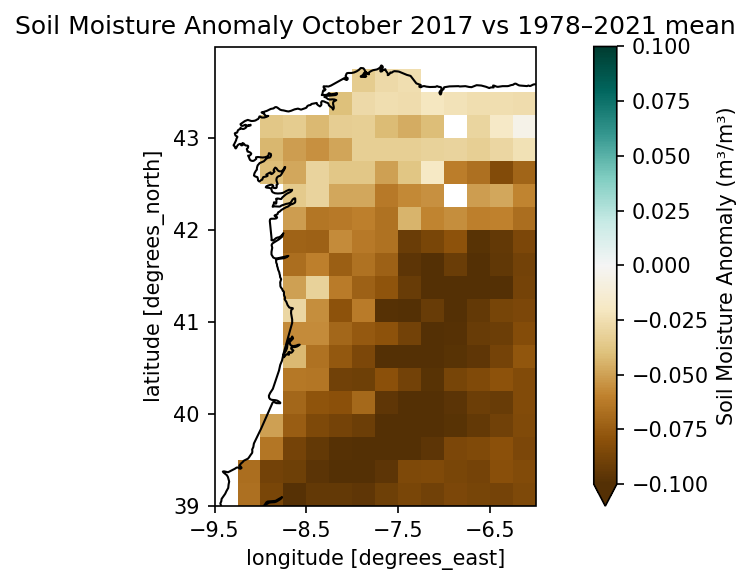

In [18]:
# Do the plotting
plot_map(
    sm_plotting.to_dataset(name="sm"), 
    var="sm", 
    title='Soil Moisture Anomaly October 2017 vs 1978–2021 mean',
    projection="PlateCarree", 
    region=bbox, 
    properties=dict(cmap='BrBG', 
                    vmin=-0.1, 
                    vmax=0.1,
                    cbar_kwargs={"label": "Soil Moisture Anomaly (m³/m³)"},
                    xticks=np.arange(bbox[0], bbox[2], 1), 
                    yticks=np.arange(bbox[1], bbox[3], 1)
                   ), 
)
plt.show()

### 💡 What do we see? 

Looking at the monthly anomaly of soil moisture, we can see that the soil has been a lot drier in October 2017 than the average. 

## Your turn: Let's explore additional ECV data

### Load and visualise the Land Surface Temperature and its anomaly to the mean.
The **Land Surface Temperature (LST)** gives us a direct thermal information of the landscape before, during, and after a fire. In the periods before a fire occurs, unusually high LST indicates a drought-stressed vegetation which favours the conditions for fires to spread. During the fire period, the LST might show us active burning areas. After the fire, the loss of vegetative cover can cause an increase in LST due to the bare areas and loss of vegetation (thus a reduced evapotranspiration and darker surface). 

➡️ ***Exercise 1: How high is the LST anomaly from 2017 compared to the average accross the whole dataset?***

In [20]:
# Type your code here:
lst_dataset = 'ESACCI-LST-L3S-LST-IRCDR_-0.01deg_1MONTHLY_DAY-1995-2020-fv3.00.zarr'



In [ ]:
# Solution to Exercise 1

# load the dataset
lst_ds, lst_name = open_data(lst_dataset, var_names="lst")
# get the spatial subset
subset_spatial_op = get_op('subset_spatial')
lst_sub = subset_spatial_op(ds=lst_ds, region=bbox_west)
# get the climatology operation
climatology_op = get_op('climatology')
lst_clim = climatology_op(ds=lst_sub)

# Define the two months to plot
dates = ['2017-09-01', '2017-10-01']
norm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=10)
# Compute the anomaly for June and plot
climatology_time = f"1995-{dates[0][5:7]}-01"
data_june = (lst_sub["lst"].sel(time=dates[0], method='nearest') -
             lst_clim["lst"].sel(time=climatology_time, method='nearest')).compute().to_dataset(name="lst")
plot_map(
    data_june,
    var="lst",
    title=str(dates[0]),
    projection="PlateCarree",
    region=bbox,
    properties=dict(cmap="bwr", 
                    norm=norm,
                    cbar_kwargs={"label": 'Land Surface Temperature Anomaly (K)'},
                    xticks=np.arange(bbox[0], bbox[2], 1), 
                    yticks=np.arange(bbox[1], bbox[3], 1)
    )
)
plt.show()

# Compute the anomaly for October and plot
climatology_time = f"1995-{dates[1][5:7]}-01"
data_october = (lst_sub["lst"].sel(time=dates[1], method='nearest') -
                lst_clim["lst"].sel(time=climatology_time, method='nearest')).compute().to_dataset(name="lst")
plot_map(
    data_october,
    var="lst",
    title=str(dates[1]),
    projection="PlateCarree",
    region=bbox,
    properties=dict(cmap="bwr", 
                    norm=norm,
                    cbar_kwargs={"label": 'Land Surface Temperature Anomaly (K)'},
                    xticks=np.arange(bbox[0], bbox[2], 1), 
                    yticks=np.arange(bbox[1], bbox[3], 1)
    )
)
plt.show()

### Check the losses and gains of the biomass before and after the wildfires. 
The [CCI Biomass](https://climate.esa.int/en/projects/biomass/) data is available in different resolutions. The list of available biomass datasets can be viewed with `list_ecv_datasets('Biomass')`. If you would like to explore a larger area, we recommend you use a biomass dataset with a lower resolution. 

Looking at the post-fire biomass compared against the pre-fire biomass, we get an understanding of how the fires damaged the vegetation. However, after a fire, biomass is also returning and growing back. Let's explore how 2017 differs from 2018. 

➡️ ***Exercise 2: Calculate the difference in biomass between 2017 and 2018 using the toolbox operator `diff`. Tipp: use a smaller area for the bbox (see below) to reduce the amount of data.***

In [21]:
# list_ecv_datasets('Biomass')

[('esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.CHANGE.4-0.r1',
  'esa-cci'),
 ('esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.CHANGE.5-0.2016-2015',
  'esa-cci'),
 ('esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.CHANGE.5-0.2017-2016',
  'esa-cci'),
 ('esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.CHANGE.5-0.2018-2017',
  'esa-cci'),
 ('esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.CHANGE.5-0.2019-2018',
  'esa-cci'),
 ('esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.CHANGE.5-0.2020-2010',
  'esa-cci'),
 ('esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.CHANGE.5-0.2020-2019',
  'esa-cci'),
 ('esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.CHANGE.5-0.2021-2020',
  'esa-cci'),
 ('esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.CHANGE.6-0.100m-2010-2007',
  'esa-cci'),
 ('esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.CHANGE.6-0.100m-2016-2015',
  'esa-cci'),
 ('esacci.BIOMASS.yr.L4.AGB.multi-sensor.multi-platform.CHANGE.6-0.

In [22]:
# Type your code here ...
biomass_dataset_100m = 'ESACCI-BIOMASS-L4-AGB-MERGED-100m-2010-2020-fv4.0.zarr'
bbox_small = (-9.0, 39.5, -7.0, 41.0) # smaller area



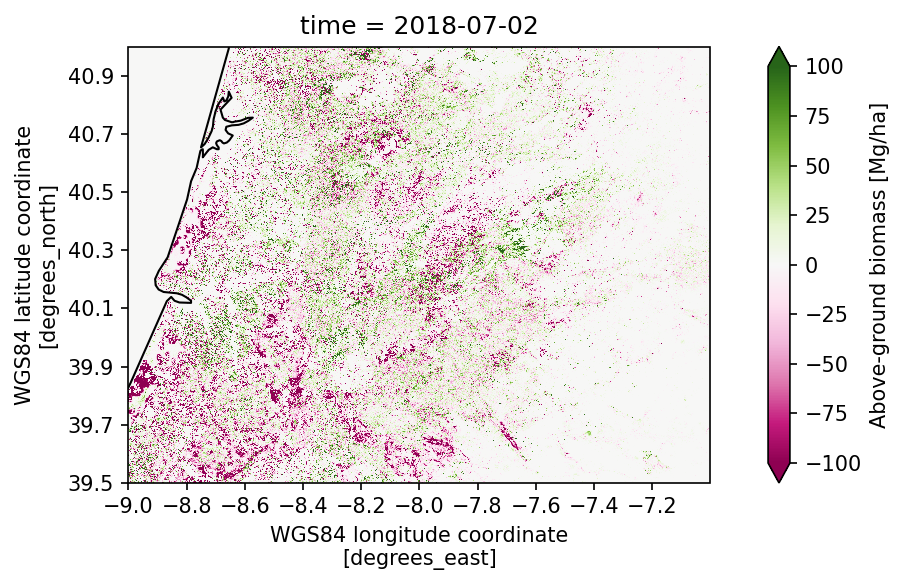

In [24]:
# Solution to Exercise 2

biomass_dataset_100m = 'ESACCI-BIOMASS-L4-AGB-MERGED-100m-2010-2020-fv4.0.zarr'
biomass_100m, biomass_name = open_data(biomass_dataset_100m,var_names="agb")
bbox_small = (-9.0, 39.5, -7.0, 41.0) # smaller area

subset_spatial_op = get_op('subset_spatial')

biomass_sub = subset_spatial_op(ds=biomass_100m, region=bbox_small)


# using the toolbox operator "diff" to calcualte the difference in agb:
from esa_climate_toolbox.ops import diff
biomass_diff = diff(
    ds = biomass_sub,
    ds2 = biomass_sub.sel(time='2017-1-1',method='nearest')
)

#
plot_map(
    biomass_diff.sel(time='2018-01-01', method='nearest'), 
    var="agb",
    projection="PlateCarree", 
    region=bbox_small, 
    properties=dict(cmap="PiYG", vmin=-100, vmax=100, xticks=np.arange(bbox_small[0], bbox_small[2], 0.2), yticks=np.arange(bbox_small[1], bbox_small[3], 0.2))
)
plt.show()

### Have a look at the carbon monoxide concentration during the fires. 

➡️ ***Exercise 3: Have a look at the CO data accross the Iberian Peninsula to see if we can spot the wildfires in 2017.***

In [25]:
# Type your code here: 
co_dataset = 'esacci.PREC.mon.L3S.CO.multi-sensor.multi-platform.IASI_MOPITT_MERGED_LATMOS-180x360_1M.1-0.r1'



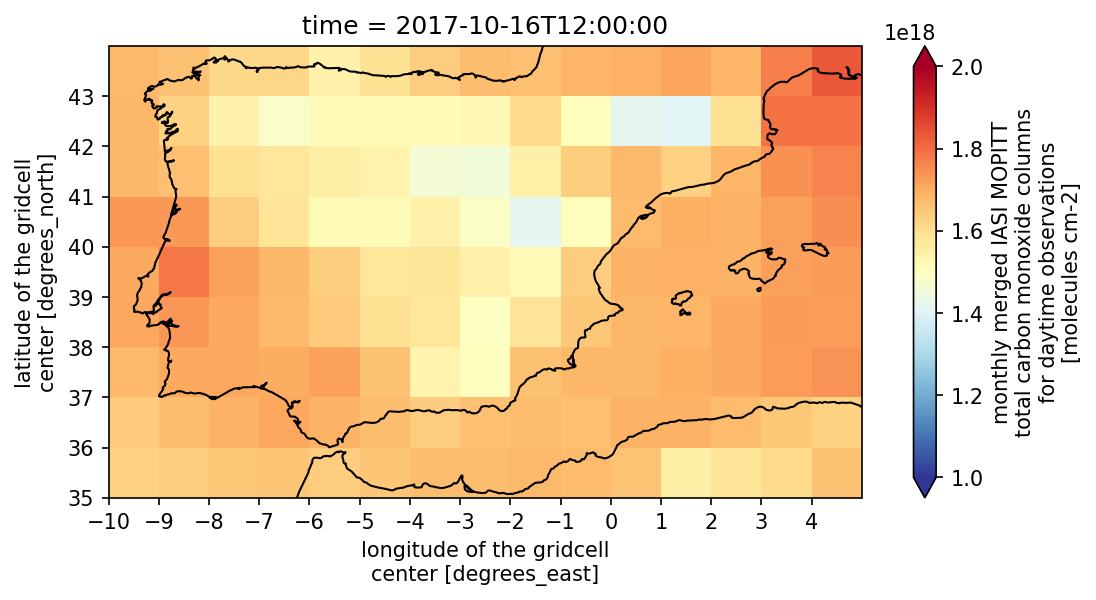

In [26]:
# Solution to Exercise 3

from matplotlib.colors import LogNorm

co_dataset = 'esacci.PREC.mon.L3S.CO.multi-sensor.multi-platform.IASI_MOPITT_MERGED_LATMOS-180x360_1M.1-0.r1'

co_ds, co_name = open_data(co_dataset,var_names="co_total_column_day")



plot_map(
    co_ds.sel(time='2017-10-16', method='nearest'), 
    var="co_total_column_day",
    projection="PlateCarree", 
    region=bbox_iberianpeninsula,
    properties=dict(cmap="RdYlBu_r", vmin=1e18, vmax=2e18, 
                    xticks=np.arange(bbox_iberianpeninsula[0], bbox_iberianpeninsula[2], 1), 
                    yticks=np.arange(bbox_iberianpeninsula[1], bbox_iberianpeninsula[3], 1))
)

### Fore advanced coders: Explore another CCI Fire dataset

If you would like to explore the pixel fire dataset, you can follow the instructions in the [**Fire Access Jupyter Notebook**](https://github.com/esa-cci/esa-climate-toolbox/blob/main/notebooks/user_examples/Fire_Access.ipynb). 
The file ID is `esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v5-1.pixel`. The data is stored as a datatree, which is why we need additional steps to open the dataset. 

The temporal resolution of the data is monthly and covers 2001 - 2022. The spatial resolution is 0.0022° which corresponds to a pixel size of approximately 250 m x 250 m on the Iberian Peninsula. The unit of the burned area is m<sup>2</sup>.


From the [Product User Guide](https://climate.esa.int/media/documents/Fire_cci_D4.2.1_PUG-MODIS_v1.1.pdf) we can get the information on the Areas. The table is also shown here for your convenince. 
For the Iberian Wildfires, we need the Area 3. 

| Area | Name | Upper Left | Lower Right |
|------|------|------------|-------------|
| 1 | North America | 180°W, 83°N | 50°W, 19°N |
| 2 | South America | 105°W, 19°N | 34°W, 57°S |
| 3 | Europe – North Africa | 26°W, 83°N | 53°E, 25°N |
| 4 | Asia | 53°E, 83°N | 180°E, 0°N |
| 5 | Sub-Saharan Africa | 26°W, 25°N | 53°E, 0°N |
| 6 | Australia & New Zealand | 95°E, 40°S | 180°E, 53°S |

In [ ]:
# Here you see the first steps to open the dataset... note that the dataset is rather large and this takes a while

# fire_pixel_dataset = "esacci.FIRE.mon.L3S.BA.MODIS.Terra.MODIS_TERRA.v5-1.pixel"

# cci_store = new_data_store('esa-cci')
# #cci_store.describe_data(fire_pixel_dataset)

# places = ["AREA_3"]

# # now we use the data file name and the places we defined to open the data tree:
# fire_dt = cci_store.open_data(
#     fire_pixel_dataset,
#     place_names=places
# )
# fire_dt